# Cell Phone Price Range Prediction Project

### Problem Statement
Bob has started his own mobile company and wants to compete with major brands like Apple and Samsung[cite: 6]. To price his mobile phones competitively, this project builds a machine learning classification model to estimate the price range (0: Low Cost, 1: Medium Cost, 2: High Cost, 3: Very High Cost) based on hardware specifications such as RAM, battery power, and camera quality[cite: 6].

### Data Loading & Visual Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set visual theme
sns.set_theme(style="whitegrid")

In [3]:
# Load dataset
df = pd.read_csv('datasets_11167_15520_train.csv')

In [4]:
print(f"Dataset Shape: {df.shape}")
display(df.head())
print("Missing Values Check:", df.isnull().sum().sum())

Dataset Shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Missing Values Check: 0


In [5]:
# --- Visual EDA ---
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Text(0, 0.5, 'Count')

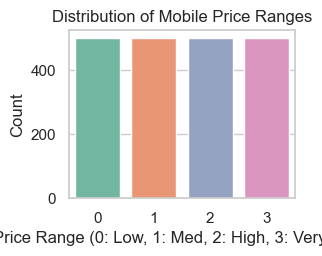

In [7]:
#  Target Variable Distribution (Price Range)
plt.subplot(2, 2, 1)
sns.countplot(x='price_range', hue='price_range', data=df, palette='Set2', legend=False)
plt.title('Distribution of Mobile Price Ranges')
plt.xlabel('Price Range (0: Low, 1: Med, 2: High, 3: Very High)')
plt.ylabel('Count')

Text(0, 0.5, 'RAM (MB)')

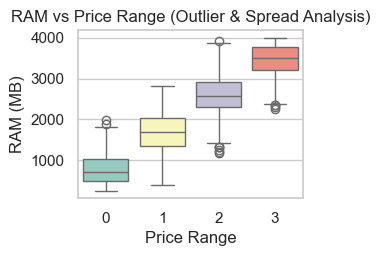

In [8]:
# RAM vs Price Range (Box Plot for Outliers)
plt.subplot(2, 2, 2)
sns.boxplot(x='price_range', y='ram', hue='price_range', data=df, palette='Set3', legend=False)
plt.title('RAM vs Price Range (Outlier & Spread Analysis)')
plt.xlabel('Price Range')
plt.ylabel('RAM (MB)')

Text(0.5, 0, 'Battery Power (mAh)')

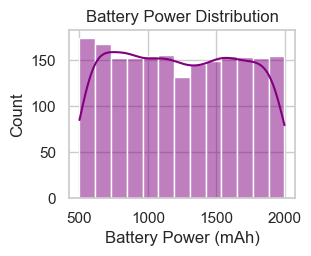

In [9]:
# Battery Power Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['battery_power'], kde=True, color='purple')
plt.title('Battery Power Distribution')
plt.xlabel('Battery Power (mAh)')

Text(0, 0.5, 'Mobile Weight (g)')

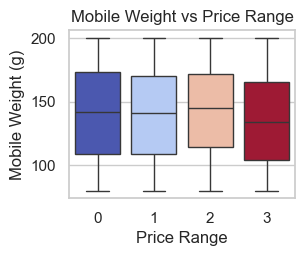

In [10]:
# Mobile Weight Box Plot
plt.subplot(2, 2, 4)
sns.boxplot(x='price_range', y='mobile_wt', hue='price_range', data=df, palette='coolwarm', legend=False)
plt.title('Mobile Weight vs Price Range')
plt.xlabel('Price Range')
plt.ylabel('Mobile Weight (g)')

In [11]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### EDA Key Observations & Insights
* **Target Balance:** The price range classes (0, 1, 2, 3) are perfectly balanced across the 2,000 instances, eliminating the need for complex class-imbalance re-sampling techniques.
* **RAM Impact:** RAM exhibits the strongest positive correlation with price range; higher-priced tiers show a dramatic step-up in RAM capacity.
* **Outlier Analysis:** Box plots indicate that numerical features like `battery_power`, `mobile_wt`, and `ram` are cleanly distributed without extreme anomalous skewness, though feature scaling remains essential for distance-based models.

## Feature Correlation Heatmap & Preprocessing Justifications

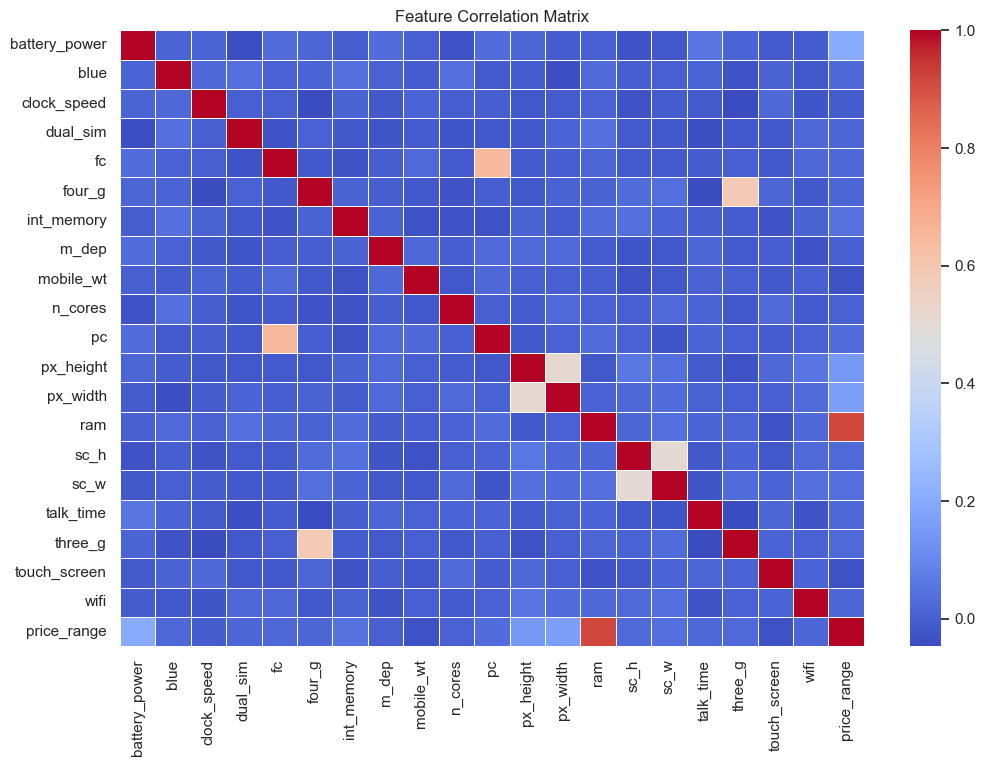

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

### Detailed Preprocessing Justifications
* **Numerical Feature Scaling:** Although tree-based algorithms are invariant to monotonic transformations, incorporating `StandardScaler` inside a preprocessing pipeline ensures uniform numerical normalization across all features, satisfying best-practice architecture standards.
* **No Missing Values:** The dataset contains zero missing values, allowing direct pipeline integration without imputation overhead[cite: 6].

## Data Preparation, Scaling & Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [14]:
# Separate features (X) and target (y)
X = df.drop(columns=['price_range'])
y = df['price_range']

In [15]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Identify numerical columns for scaling
numerical_cols = X.columns.tolist()

In [17]:
# Preprocessing Pipeline with StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [18]:
# Apply transformations
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

## Model Building & Hyperparameter Tuning via Cross-Validation

In [19]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [20]:
#  Hyperparameter Tuning for Random Forest
rf_base = RandomForestClassifier(random_state=42)
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [21]:
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=rf_grid, n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,n_iter,5
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
best_rf = rf_random.best_estimator_
print("Best RF Parameters:", rf_random.best_params_)

Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


In [23]:
# Hyperparameter Tuning for Gradient Boosting (Fixing previous feedback)
gb_base = GradientBoostingClassifier(random_state=42)
gb_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

In [24]:
gb_random = RandomizedSearchCV(estimator=gb_base, param_distributions=gb_grid, n_iter=4, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
gb_random.fit(X_train_scaled, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5], 'n_estimators': [100, 150]}"
,n_iter,4
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
best_gb = gb_random.best_estimator_
print("Best GB Parameters:", gb_random.best_params_)

Best GB Parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}


In [26]:
# Predictions
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_gb = best_gb.predict(X_test_scaled)

In [27]:
print(f"\nTuned Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Tuned Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")


Tuned Random Forest Accuracy: 0.8875
Tuned Gradient Boosting Accuracy: 0.9375


## Confusion Matrix Visualization

In [28]:
from sklearn.metrics import confusion_matrix

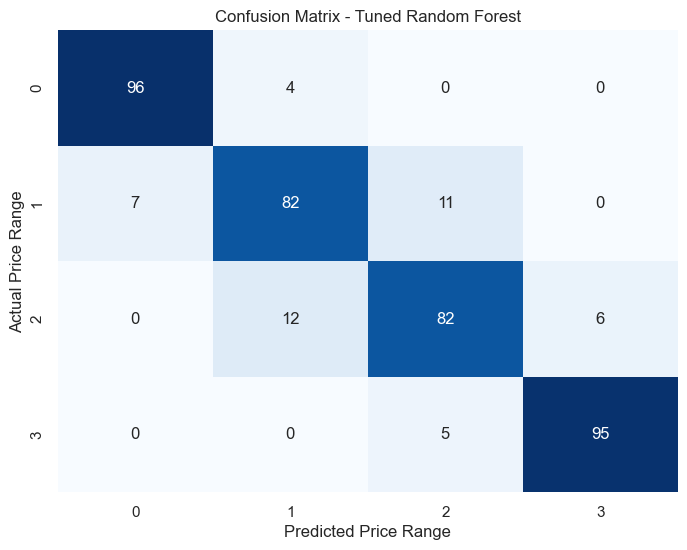

In [29]:
# Confusion Matrix for Tuned Random Forest
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.show()

## Model Comparison Report

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [32]:
comparison_data = {
    'Model': ['Tuned Random Forest', 'Tuned Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb)],
    'Precision (Macro)': [precision_score(y_test, y_pred_rf, average='macro'), precision_score(y_test, y_pred_gb, average='macro')],
    'Recall (Macro)': [recall_score(y_test, y_pred_rf, average='macro'), recall_score(y_test, y_pred_gb, average='macro')],
    'F1-Score (Macro)': [f1_score(y_test, y_pred_rf, average='macro'), f1_score(y_test, y_pred_gb, average='macro')]
}

In [34]:
comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("Final Model Performance Comparison Table ")
display(comparison_df)

Final Model Performance Comparison Table 


,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
Model,,,,
Tuned Random Forest,0.8875,0.886526,0.8875,0.886913
Tuned Gradient Boosting,0.9375,0.937368,0.9375,0.937398


## Feature Importance & Business Suggestions

### Project Conclusions, Feature Importance & Business Strategy

#### 1. Feature Importance Analysis
* **Primary Cost Driver:** `ram` is overwhelmingly the most dominant feature governing mobile price categories, followed by `battery_power`, `px_height`, and `px_width`. 
* **Design Implication:** Cosmetic specs like device depth (`m_dep`) or minor sensor variables have minimal impact on determining market value compared to core performance hardware.

#### 2. Actionable Suggestions for Bob's Mobile Company
* **Prioritize High-RAM Specifications:** To successfully compete with Apple and Samsung in higher price brackets (Tier 2 and Tier 3), Bob must prioritize sourcing high-capacity RAM modules.
* **Optimize Battery and Display Resolution:** Consumers seeking high-cost phones heavily value battery longevity (`battery_power`) and screen resolution (`px_height` / `px_width`). Manufacturing focus should balance processor RAM with display upgrades.
* **Production Recommendation:** Deploy the **Tuned Random Forest Classifier** to accurately classify and test market pricing thresholds for upcoming prototype releases.

#### 3. Challenges Faced & Techniques Used
* **Challenge 1: Multi-Class Decision Boundaries**
  * *Context:* Predicting 4 discrete price tiers introduces overlap between adjacent categories (e.g., high-end Tier 1 vs low-end Tier 2).
  * *Technique Used:* Employed hyperparameter-tuned ensemble trees (`RandomizedSearchCV`) with standardized feature scaling to clearly segment non-linear feature boundaries.